In [2]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
import os
from PIL import Image
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.models import Sequential
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc



In [239]:
sample_car_path = r"C:\Users\aymna\OneDrive - UMM AL-QURA UNIVERSITY\السنة الثالثة الترم الأول\نمذجة البيانات\data\project_data\v_data\train\cars\9.jpg"
sample_plane_path = r"C:\Users\aymna\OneDrive - UMM AL-QURA UNIVERSITY\السنة الثالثة الترم الأول\نمذجة البيانات\data\project_data\v_data\train\planes\2.jpg"

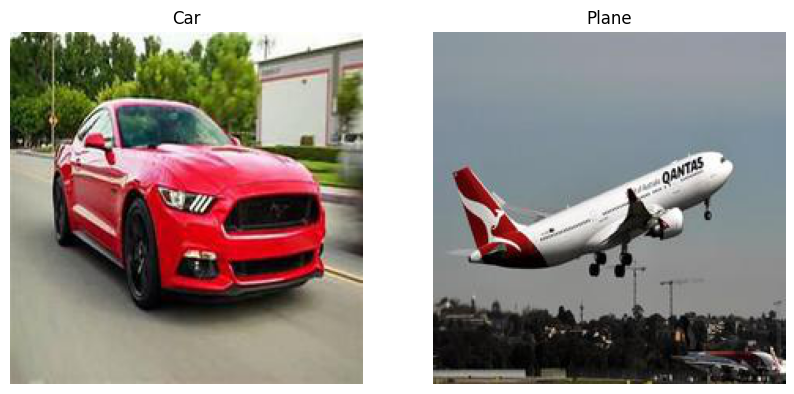

In [241]:
# Load and display sample images
car_img = Image.open(sample_car_path)
plane_img = Image.open(sample_plane_path)

# Display images
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(car_img)
ax[0].set_title("Car")
ax[0].axis("off")

ax[1].imshow(plane_img)
ax[1].set_title("Plane")
ax[1].axis("off")

plt.show()

In [243]:
train_dir = r"C:\Users\aymna\OneDrive - UMM AL-QURA UNIVERSITY\السنة الثالثة الترم الأول\نمذجة البيانات\data\project_data\v_data\train"
test_dir = r"C:\Users\aymna\OneDrive - UMM AL-QURA UNIVERSITY\السنة الثالثة الترم الأول\نمذجة البيانات\data\project_data\v_data\test"



In [245]:
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=16,
    class_mode='binary'
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=16,
    class_mode='binary'
)

Found 401 images belonging to 2 classes.
Found 100 images belonging to 2 classes.


# CNN Model 

In [83]:
#lable data with 0 and1

In [247]:
from PIL import Image
import numpy as np
import os
from sklearn.model_selection import train_test_split

# Parameters
img_size = 224  # Desired image size
train_dir = r"C:\Users\aymna\OneDrive - UMM AL-QURA UNIVERSITY\السنة الثالثة الترم الأول\نمذجة البيانات\data\project_data\v_data\train"  

# Lists to hold image data and labels
x_data = []
y_data = []

# Loop through categories and load images
for label, category in enumerate(['cars', 'planes']):
    category_path = os.path.join(train_dir, category)
    if not os.path.isdir(category_path):
        print(f"Directory not found: {category_path}")
        continue
    for img_name in os.listdir(category_path):
        img_path = os.path.join(category_path, img_name)
        try:
            # Load image with PIL, resize, and convert to array
            with Image.open(img_path) as img:
                img = img.resize((img_size, img_size))
                img = np.array(img)  # Convert to numpy array
                x_data.append(img)
                y_data.append(label)
        except Exception as e:
            print(f"Error loading image {img_path}: {e}")

# Convert lists to arrays
x_data = np.array(x_data) / 255.0  # Normalize pixel values to [0, 1]
y_data = np.array(y_data)

# Print the number of loaded images
print(f"Number of images loaded: {len(x_data)}")

# Split into training and validation sets
x_train, x_val, y_train, y_val = train_test_split(x_data, y_data, test_size=0.2, random_state=42)

# Reshape if required by your CNN model 
x_train = x_train.reshape(-1, img_size, img_size, 3)
x_val = x_val.reshape(-1, img_size, img_size, 3)

# Confirm data shapes
print(f"x_train shape: {x_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"x_val shape: {x_val.shape}")
print(f"y_val shape: {y_val.shape}")


Number of images loaded: 401
x_train shape: (320, 224, 224, 3)
y_train shape: (320,)
x_val shape: (81, 224, 224, 3)
y_val shape: (81,)


C:\Users\aymna\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_53"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_161 (Dense)               │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_129 (Dropout)           │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_162 (Dense)               │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.4890 - loss: 1.3028 - val_accuracy: 0.4444 - val_loss: 0.7140
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.5536 - loss: 0.6673 - val_accuracy: 0.5802 - val_loss: 0.6392
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.7166 - loss: 0.5642 - val_accuracy: 0.6790 - val_loss: 0.5416
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.7526 - loss: 0.5238 - val_accuracy: 0.7778 - val_loss: 0.4348
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.8563 - loss: 0.3475 - val_accuracy: 0.7778 - val_loss: 0.4519
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.8922 - loss: 0.2734 - val_accuracy: 0.7531 - val_loss: 0.4489
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.9009 - loss: 0.2594 - val_accuracy: 0.7531 - val_loss: 0.4979
Epoch 8/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.8908 - loss: 0.2746 - val_accuracy: 0.8889 - val_loss:

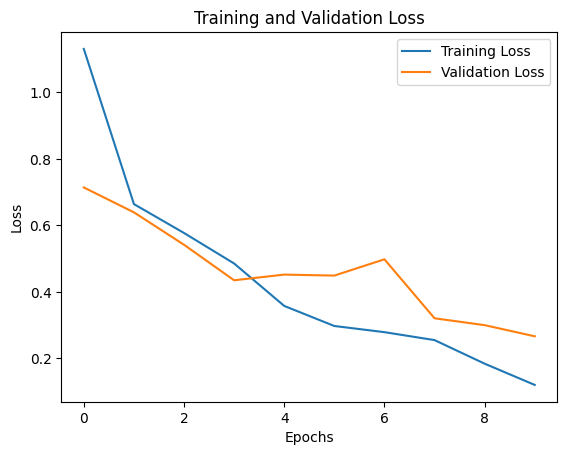

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 336ms/step
Classification Report:
               precision    recall  f1-score   support

         Car       0.93      0.87      0.90        45
       Plane       0.85      0.92      0.88        36

    accuracy                           0.89        81
   macro avg       0.89      0.89      0.89        81
weighted avg       0.89      0.89      0.89        81

Confusion Matrix:
 [[39  6]
 [ 3 33]]


In [249]:

#  CNN model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    MaxPooling2D(2, 2),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

# Train the model
history = model.fit(x_train, y_train, epochs=10, batch_size=32, validation_data=(x_val, y_val))

# Plot training and validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

# Evaluate model on validation data
predictions = model.predict(x_val)
predicted_classes = (predictions > 0.5).astype("int32").flatten()

# Print classification report
print("Classification Report:\n", classification_report(y_val, predicted_classes, target_names=['Car', 'Plane']))

# Print confusion matrix
conf_matrix = confusion_matrix(y_val, predicted_classes)
print("Confusion Matrix:\n", conf_matrix)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step


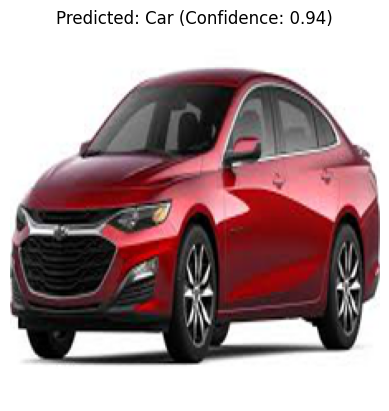

In [251]:
# test the model 


def prepare_image(img_path, img_size=224):
    with Image.open(img_path) as img:
        img = img.resize((img_size, img_size))  # Resize to the input size
        img_array = np.array(img) / 255.0       # Normalize pixel values to [0, 1]
        img_array = img_array.reshape(-1, img_size, img_size, 3)  # Reshape for model
    return img_array, img  # Return both the array for prediction and the PIL image for display

# Predict class and display the image with the result and confidence score
def predict_and_display_image_class(model, img_path):
    img_array, img = prepare_image(img_path)
    prediction_prob = model.predict(img_array)[0, 0]  # Get the prediction probability
    
    
    predicted_class = "Plane" if prediction_prob > 0.5 else "Car"
    confidence = prediction_prob if prediction_prob > 0.5 else 1 - prediction_prob  # Confidence as probability
    
    
    plt.imshow(img)
    plt.title(f"Predicted: {predicted_class} (Confidence: {confidence:.2f})")
    plt.axis('off')  # Hide axes
    plt.show()


img_path =r"C:\Users\aymna\Downloads\تنزيل.jpg" 
predict_and_display_image_class(model, img_path)


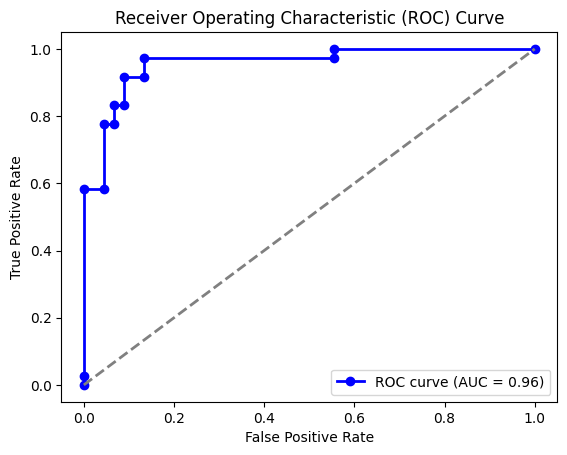

In [253]:
# ROC curve

from sklearn.metrics import roc_curve, auc
fpr, tpr, thresholds = roc_curve(y_val,predictions )


roc_auc = auc(fpr, tpr)


plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})', marker='o')  
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--') 
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()


# RNN Model

In [259]:
img_size = 224  # Resize all images to 224x224 pixels


x_data = []
y_data = []

# Load images and assign labels (0 for 'cars' and 1 for 'planes')
for label, category in enumerate(['cars', 'planes']):
    category_path = os.path.join(train_dir, category)
    if not os.path.isdir(category_path):
        print(f"Directory not found: {category_path}")
        continue
    for img_name in os.listdir(category_path):
        img_path = os.path.join(category_path, img_name)
        try:
            # Load image with PIL, resize, and convert to numpy array
            with Image.open(img_path) as img:
                img = img.resize((img_size, img_size))
                img = np.array(img)  # Convert to numpy array
                x_data.append(img)
                y_data.append(label)
        except Exception as e:
            print(f"Error loading image {img_path}: {e}")

# Convert lists to arrays
x_data = np.array(x_data) / 255.0  # Normalize pixel values to [0, 1]
y_data = np.array(y_data)

In [260]:

x_train, x_val, y_train, y_val = train_test_split(x_data, y_data, test_size=0.2, random_state=42)

# Reshape data for RNN model
# Each row of pixels is treated as a time step; we flatten the width and channels
x_train_rnn = x_train.reshape(-1, img_size, img_size * 3)
x_val_rnn = x_val.reshape(-1, img_size, img_size * 3)


print(f"x_train_rnn shape: {x_train_rnn.shape}")
print(f"x_val_rnn shape: {x_val_rnn.shape}")

x_train_rnn shape: (320, 224, 672)
x_val_rnn shape: (81, 224, 672)


In [263]:
model = Sequential([
    LSTM(128, input_shape=(img_size, img_size * 3), return_sequences=True),
    Dropout(0.2),
    LSTM(64),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

C:\Users\aymna\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_54"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_24 (LSTM)                  │ (None, 224, 128)       │       410,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_130 (Dropout)           │ (None, 224, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_25 (LSTM)                  │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_131 (Dropout)           │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_163 (Dense)               │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 459,585 (1.75 MB)

 Trainable params: 459,585 (1.75 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/12
10/10 ━━━━━━━━━━━━━━━━━━━━ 15s 668ms/step - accuracy: 0.4875 - loss: 0.7864 - val_accuracy: 0.4321 - val_loss: 0.7834
Epoch 2/12
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 508ms/step - accuracy: 0.5098 - loss: 0.7155 - val_accuracy: 0.5556 - val_loss: 0.6841
Epoch 3/12
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 466ms/step - accuracy: 0.5239 - loss: 0.6907 - val_accuracy: 0.4691 - val_loss: 0.6952
Epoch 4/12
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 463ms/step - accuracy: 0.5923 - loss: 0.6735 - val_accuracy: 0.5062 - val_loss: 0.6927
Epoch 5/12
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 462ms/step - accuracy: 0.5696 - loss: 0.6595 - val_accuracy: 0.4938 - val_loss: 0.6974
Epoch 6/12
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 449ms/step - accuracy: 0.6057 - loss: 0.6644 - val_accuracy: 0.4938 - val_loss: 0.7038
Epoch 7/12
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 466ms/step - accuracy: 0.6636 - loss: 0.6267 - val_accuracy: 0.4938 - val_loss: 0.6963
Epoch 8/12
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 439ms/step - accuracy: 0.5876 - loss: 0.6466 - val_accuracy: 0

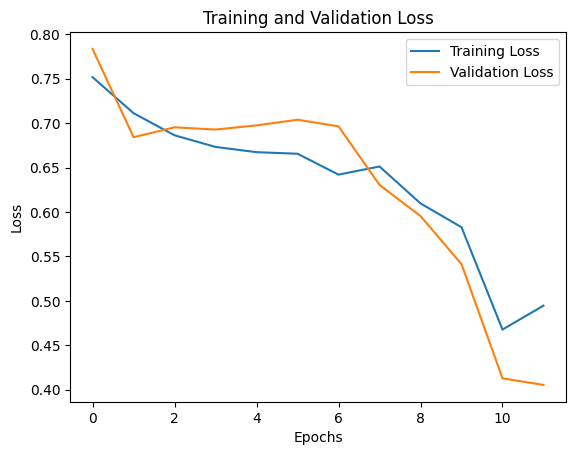

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 675ms/step
Classification Report:
               precision    recall  f1-score   support

         Car       0.86      0.84      0.85        45
       Plane       0.81      0.83      0.82        36

    accuracy                           0.84        81
   macro avg       0.84      0.84      0.84        81
weighted avg       0.84      0.84      0.84        81

Confusion Matrix:
 [[38  7]
 [ 6 30]]


In [265]:

history = model.fit(x_train_rnn, y_train, epochs=12, batch_size=32, validation_data=(x_val_rnn, y_val))

# Plot training and validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

# Evaluate model on validation data
predictions = (model.predict(x_val_rnn) > 0.5).astype("int32").flatten()


print("Classification Report:\n", classification_report(y_val, predictions, target_names=['Car', 'Plane']))


conf_matrix = confusion_matrix(y_val, predictions)
print("Confusion Matrix:\n", conf_matrix)


3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 177ms/step


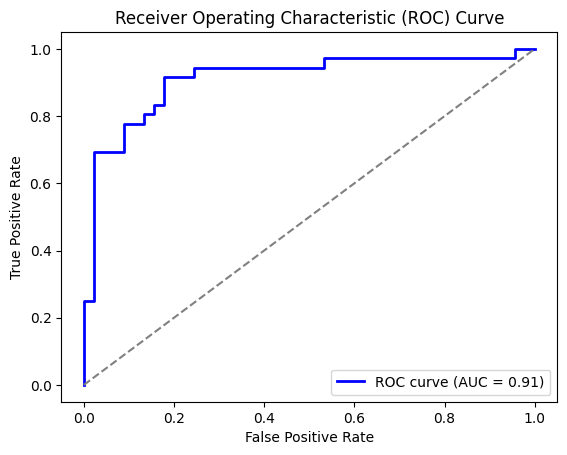

In [267]:
#ROC curve


def plot_roc_curve(model, x_val, y_val):
    # Get the probabilities for the validation set
    y_pred_prob = model.predict(x_val).ravel()
    
    # Calculate False Positive Rate, True Positive Rate, and thresholds
    fpr, tpr, thresholds = roc_curve(y_val, y_pred_prob)
    roc_auc = auc(fpr, tpr)

    # Plot ROC Curve
    plt.figure()
    plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    plt.show()


plot_roc_curve(model, x_val_rnn, y_val)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
Predicted Class: Plane


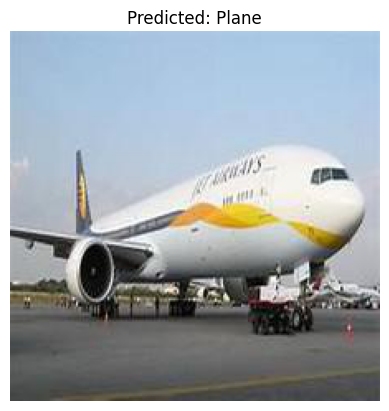

In [271]:
# test the model

def predict_single_image(model, img_path, img_size=224):
    try:
        # Load and preprocess the image
        with Image.open(img_path) as img:
            img = img.resize((img_size, img_size))
            img_array = np.array(img) / 255.0  # Normalize pixel values
            img_array = img_array.reshape(1, img_size, img_size * 3)  # Reshape for the model

        # Predict
        prediction_prob = model.predict(img_array)[0, 0]
        prediction_class = "Plane" if prediction_prob > 0.5 else "Car"

        # Output result
        print(f"Predicted Class: {prediction_class}")

        # Show the image
        plt.imshow(img)
        plt.title(f"Predicted: {prediction_class}")
        plt.axis('off')
        plt.show()
    except Exception as e:
        print(f"Error loading or predicting image: {e}")


img_path = r"C:\Users\aymna\OneDrive - UMM AL-QURA UNIVERSITY\السنة الثالثة الترم الأول\نمذجة البيانات\data\project_data\v_data\test\planes\5.jpg" 
predict_single_image(model, img_path)

# FNN Model

C:\Users\aymna\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_52"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_157 (Dense)               │ (None, 256)            │    38,535,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_158 (Dense)               │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_159 (Dense)               │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_160 (Dense)               │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,576,641 (147.16 MB)

 Trainable params: 38,576,641 (147.16 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 9s 423ms/step - binary_accuracy: 0.5039 - loss: 25.6713 - val_binary_accuracy: 0.5207 - val_loss: 17.3807
Epoch 2/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 344ms/step - binary_accuracy: 0.5103 - loss: 13.0866 - val_binary_accuracy: 0.4876 - val_loss: 14.5069
Epoch 3/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 345ms/step - binary_accuracy: 0.5929 - loss: 7.8155 - val_binary_accuracy: 0.8017 - val_loss: 1.3629
Epoch 4/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 310ms/step - binary_accuracy: 0.6985 - loss: 2.4668 - val_binary_accuracy: 0.8099 - val_loss: 1.3612
Epoch 5/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 333ms/step - binary_accuracy: 0.7356 - loss: 1.9788 - val_binary_accuracy: 0.6942 - val_loss: 2.6348
Epoch 6/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 331ms/step - binary_accuracy: 0.7151 - loss: 1.9312 - val_binary_accuracy: 0.6529 - val_loss: 2.8673
Epoch 7/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 321ms/step - binary_accuracy: 0.7654 - loss: 1.3906 - val_binary_accuracy: 0.8099 - val_loss: 0.9673
Epoch 8/10
9/9 ━

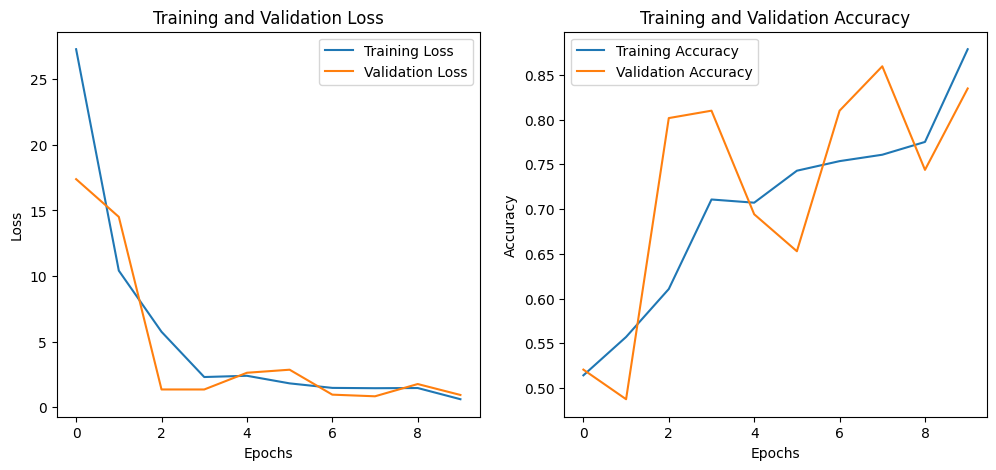

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
Classification Report:
               precision    recall  f1-score   support

        cars       0.89      0.78      0.83        63
      planes       0.79      0.90      0.84        58

    accuracy                           0.83       121
   macro avg       0.84      0.84      0.83       121
weighted avg       0.84      0.83      0.83       121

Confusion Matrix:
 [[49 14]
 [ 6 52]]


In [215]:
img_size = 224  
data_dir = r"C:\Users\aymna\OneDrive - UMM AL-QURA UNIVERSITY\السنة الثالثة الترم الأول\نمذجة البيانات\data\project_data\v_data\train"
categories = ['cars', 'planes']  # Classes
input_shape = img_size * img_size * 3

def load_and_preprocess_images(data_dir, img_size, categories):
    x_data = []
    y_data = []
    
    for label, category in enumerate(categories):
        category_path = os.path.join(data_dir, category)
        for img_name in os.listdir(category_path):
            img_path = os.path.join(category_path, img_name)
            try:
                # Load and resize image
                img = load_img(img_path, target_size=(img_size, img_size))
                # Convert image to array and normalize to range [0, 1]
                img_array = img_to_array(img) / 255.0
                # Flatten the image to a 1D array
                img_flattened = img_array.flatten()
                # Append the flattened image and label to the data lists
                x_data.append(img_flattened)
                y_data.append(label)
            except Exception as e:
                print(f"Error loading image {img_path}: {e}")
    
    return np.array(x_data), np.array(y_data)


x_data, y_data = load_and_preprocess_images(data_dir, img_size, categories)


x_train, x_val, y_train, y_val = train_test_split(x_data, y_data, test_size=0.3, random_state=42)

model = Sequential([
    Dense(256, activation='relu', input_shape=(input_shape,)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])


model.compile(optimizer=Adam(learning_rate=0.001),
              loss=BinaryCrossentropy(),
              metrics=[BinaryAccuracy()])


model.summary()


history = model.fit(x_train, y_train, batch_size=32, epochs=10, validation_data=(x_val, y_val))


val_loss, val_acc = model.evaluate(x_val, y_val)
print(f'\nValidation accuracy: {val_acc}')

# Plot training history
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')

plt.subplot(1, 2, 2)
plt.plot(history.history['binary_accuracy'], label='Training Accuracy')
plt.plot(history.history['val_binary_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.show()

y_pred = (model.predict(x_val) > 0.5).astype("int32").flatten()
print("Classification Report:\n", classification_report(y_val, y_pred, target_names=categories, zero_division=0))


conf_matrix = confusion_matrix(y_val, y_pred)
print("Confusion Matrix:\n", conf_matrix)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
Predicted Class: Car


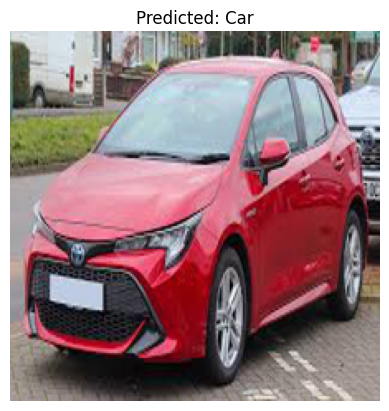

In [231]:
# Function to predict a single image's class
def predict_single_image(model, img_path, img_size=224):
    try:
        # Load and preprocess the image
        with Image.open(img_path) as img:
            img = img.resize((img_size, img_size))
            img_array = np.array(img) / 255.0  # Normalize pixel values
            img_flattened = img_array.flatten().reshape(1, img_size * img_size * 3)  # Flatten and reshape for the model

        # Predict the class
        prediction_prob = model.predict(img_flattened)[0, 0]
        prediction_class = "Plane" if prediction_prob > 0.5 else "Car"

        # Output result
        print(f"Predicted Class: {prediction_class}")

        # Display the image with the predicted class
        plt.imshow(img)
        plt.title(f"Predicted: {prediction_class}")
        plt.axis('off')
        plt.show()

    except Exception as e:
        print(f"Error loading or predicting image: {e}")


img_path = r"C:\Users\aymna\Downloads\تنزيل (3).jpg" 
predict_single_image(model, img_path)
